# Exploratory Data Analysis (EDA)

## Objective

This notebook explores the cleaned Global Electronics Retail dataset to uncover business insights that will support decision-making and dashboard development.

### Business Questions

- What is the total revenue?
- Which products generate the highest sales?
- Which countries contribute the most revenue?
- What are the monthly sales trends?
- Which customer segments perform best?

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

## Load Cleaned Datasets

In [31]:
customers = pd.read_csv("../data/customers_cleaned.csv")
products = pd.read_csv("../data/products_cleaned.csv")
sales = pd.read_csv("../data/sales_cleaned.csv")
stores = pd.read_csv("../data/stores_cleaned.csv")
exchange = pd.read_csv("../data/exchange_rates_cleaned.csv")

## Dataset Preview

In [32]:
display(customers.head())
display(products.head())
display(sales.head())
display(stores.head())
display(exchange.head())

,customerkey,gender,name,city,state_code,state,zip_code,country,continent,birthday
0,301,Female,Lilly Harding,WANDEARAH EAST,SA,South Australia,5523,Australia,Australia,7/3/1939
1,325,Female,Madison Hull,MOUNT BUDD,WA,Western Australia,6522,Australia,Australia,9/27/1979
2,554,Female,Claire Ferres,WINJALLOK,VIC,Victoria,3380,Australia,Australia,5/26/1947
3,786,Male,Jai Poltpalingada,MIDDLE RIVER,SA,South Australia,5223,Australia,Australia,9/17/1957
4,1042,Male,Aidan Pankhurst,TAWONGA SOUTH,VIC,Victoria,3698,Australia,Australia,11/19/1965


,productkey,product_name,brand,color,unit_cost_usd,unit_price_usd,subcategorykey,subcategory,categorykey,category
0,1,Contoso 512MB MP3 Player E51 Silver,Contoso,Silver,$6.62,$12.99,101,MP4&MP3,1,Audio
1,2,Contoso 512MB MP3 Player E51 Blue,Contoso,Blue,$6.62,$12.99,101,MP4&MP3,1,Audio
2,3,Contoso 1G MP3 Player E100 White,Contoso,White,$7.40,$14.52,101,MP4&MP3,1,Audio
3,4,Contoso 2G MP3 Player E200 Silver,Contoso,Silver,$11.00,$21.57,101,MP4&MP3,1,Audio
4,5,Contoso 2G MP3 Player E200 Red,Contoso,Red,$11.00,$21.57,101,MP4&MP3,1,Audio


,order_number,line_item,order_date,delivery_date,customerkey,storekey,productkey,quantity,currency_code
0,366000,1,1/1/2016,NaN,265598,10,1304,1,CAD
1,366001,1,1/1/2016,1/13/2016,1269051,0,1048,2,USD
2,366001,2,1/1/2016,1/13/2016,1269051,0,2007,1,USD
3,366002,1,1/1/2016,1/12/2016,266019,0,1106,7,CAD
4,366002,2,1/1/2016,1/12/2016,266019,0,373,1,CAD


,storekey,country,state,square_meters,open_date
0,1,Australia,Australian Capital Territory,595.0,1/1/2008
1,2,Australia,Northern Territory,665.0,1/12/2008
2,3,Australia,South Australia,2000.0,1/7/2012
3,4,Australia,Tasmania,2000.0,1/1/2010
4,5,Australia,Victoria,2000.0,12/9/2015


,date,currency,exchange
0,1/1/2015,USD,1.0000
1,1/1/2015,CAD,1.1583
2,1/1/2015,AUD,1.2214
3,1/1/2015,EUR,0.8237
4,1/1/2015,GBP,0.6415


# Business Question 1

## What is the total revenue generated?

In [33]:
sales.columns

Index(['order_number', 'line_item', 'order_date', 'delivery_date',
       'customerkey', 'storekey', 'productkey', 'quantity', 'currency_code'],
      dtype='object')

In [34]:
sales.head()

,order_number,line_item,order_date,delivery_date,customerkey,storekey,productkey,quantity,currency_code
0,366000,1,1/1/2016,NaN,265598,10,1304,1,CAD
1,366001,1,1/1/2016,1/13/2016,1269051,0,1048,2,USD
2,366001,2,1/1/2016,1/13/2016,1269051,0,2007,1,USD
3,366002,1,1/1/2016,1/12/2016,266019,0,1106,7,CAD
4,366002,2,1/1/2016,1/12/2016,266019,0,373,1,CAD


## Business Question 2

### Inspect Product Information

The Products table contains product details including price, category, and brand. This information will be combined with sales transactions to calculate revenue.

In [35]:
products.columns

Index(['productkey', 'product_name', 'brand', 'color', 'unit_cost_usd',
       'unit_price_usd', 'subcategorykey', 'subcategory', 'categorykey',
       'category'],
      dtype='object')

In [36]:
products.head()

,productkey,product_name,brand,color,unit_cost_usd,unit_price_usd,subcategorykey,subcategory,categorykey,category
0,1,Contoso 512MB MP3 Player E51 Silver,Contoso,Silver,$6.62,$12.99,101,MP4&MP3,1,Audio
1,2,Contoso 512MB MP3 Player E51 Blue,Contoso,Blue,$6.62,$12.99,101,MP4&MP3,1,Audio
2,3,Contoso 1G MP3 Player E100 White,Contoso,White,$7.40,$14.52,101,MP4&MP3,1,Audio
3,4,Contoso 2G MP3 Player E200 Silver,Contoso,Silver,$11.00,$21.57,101,MP4&MP3,1,Audio
4,5,Contoso 2G MP3 Player E200 Red,Contoso,Red,$11.00,$21.57,101,MP4&MP3,1,Audio


## Business Question 3

### Merge Sales and Products

The Sales dataset contains transaction details, while the Products dataset contains pricing information.

To calculate revenue and profit, both datasets are merged using the Product Key.

In [37]:
sales_products = sales.merge(
    products,
    on="productkey",
    how="left"
)

sales_products.head()

,order_number,line_item,order_date,delivery_date,customerkey,storekey,productkey,quantity,currency_code,product_name,brand,color,unit_cost_usd,unit_price_usd,subcategorykey,subcategory,categorykey,category
0,366000,1,1/1/2016,NaN,265598,10,1304,1,CAD,Contoso Lens Adapter M450 White,Contoso,White,$31.27,$68.00,406,Cameras & Camcorders Accessories,4,Cameras and camcorders
1,366001,1,1/1/2016,1/13/2016,1269051,0,1048,2,USD,A. Datum SLR Camera X136 Silver,A. Datum,Silver,$141.47,$427.00,402,Digital SLR Cameras,4,Cameras and camcorders
2,366001,2,1/1/2016,1/13/2016,1269051,0,2007,1,USD,Fabrikam Microwave 1.5CuFt X1100 Black,Fabrikam,Black,$220.64,$665.94,803,Microwaves,8,Home Appliances
3,366002,1,1/1/2016,1/12/2016,266019,0,1106,7,CAD,Contoso SLR Camera M146 Orange,Contoso,Orange,$148.08,$322.00,402,Digital SLR Cameras,4,Cameras and camcorders
4,366002,2,1/1/2016,1/12/2016,266019,0,373,1,CAD,Adventure Works Laptop8.9 E0890 White,Adventure Works,White,$166.20,$326.00,301,Laptops,3,Computers


## Calculate Revenue

In [38]:
sales_products["unit_price_usd"] = (
    sales_products["unit_price_usd"]
    .replace(r"[$,]", "", regex=True)
    .astype(float)
)

In [39]:
sales_products["Revenue"] = (
    sales_products["quantity"] *
    sales_products["unit_price_usd"]
)

In [40]:
sales_products[[
    "product_name",
    "quantity",
    "unit_price_usd",
    "Revenue"
]].head()

,product_name,quantity,unit_price_usd,Revenue
0,Contoso Lens Adapter M450 White,1,68.00,68.00
1,A. Datum SLR Camera X136 Silver,2,427.00,854.00
2,Fabrikam Microwave 1.5CuFt X1100 Black,1,665.94,665.94
3,Contoso SLR Camera M146 Orange,7,322.00,2254.00
4,Adventure Works Laptop8.9 E0890 White,1,326.00,326.00


## KPI 1 - Total Revenue

In [41]:
total_revenue = sales_products["Revenue"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $55,755,479.59


## Business Question 4

### Top 10 Products by Revenue

In [42]:
top_products = (
    sales_products
    .groupby("product_name")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

product_name
WWI Desktop PC2.33 X2330 Black                 505450.00
Adventure Works Desktop PC2.33 XD233 Silver    466089.00
Adventure Works Desktop PC2.33 XD233 Brown     464151.00
Adventure Works Desktop PC2.33 XD233 Black     447678.00
Adventure Works Desktop PC2.33 XD233 White     437019.00
WWI Desktop PC2.33 X2330 White                 424578.00
WWI Desktop PC2.33 X2330 Brown                 422740.00
Adventure Works 52" LCD HDTV X590 White        394398.64
Adventure Works 52" LCD HDTV X590 Black        374098.71
WWI Desktop PC2.33 X2330 Silver                360248.00
Name: Revenue, dtype: float64

## Visualization - Top 10 Products by Revenue

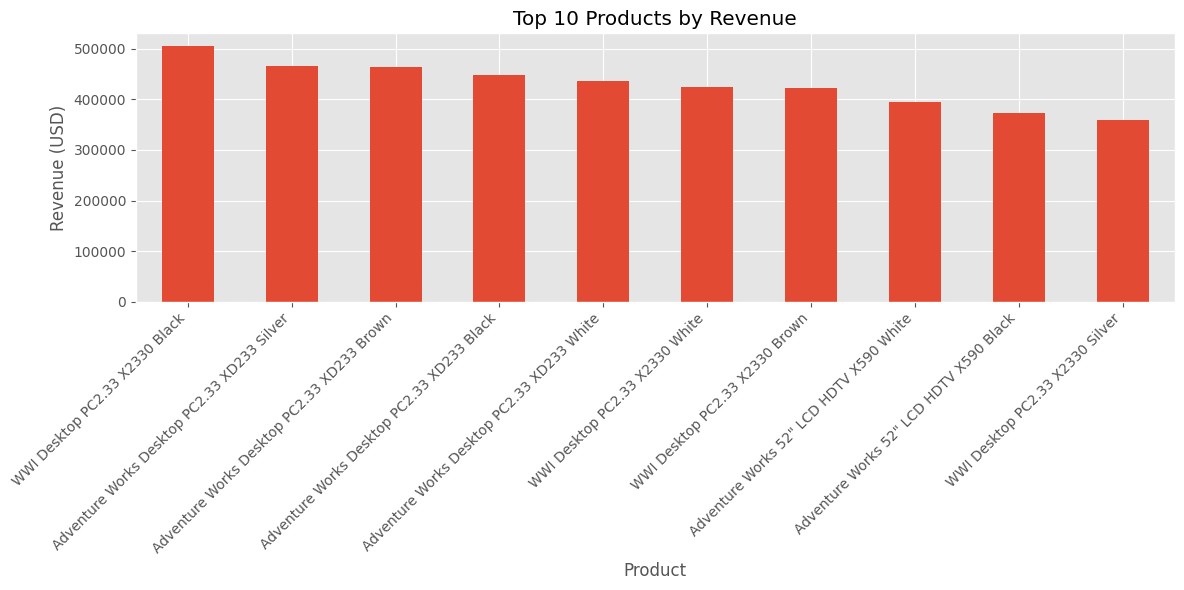

In [43]:
plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue (USD)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

### Insight

The visualization highlights the ten highest revenue-generating products. These products represent the strongest contributors to overall business revenue and should be prioritized for inventory planning, marketing campaigns, and demand forecasting.

# Business Question 5

## Which product categories generate the highest revenue?

Understanding category performance helps management identify high-performing business segments and optimize inventory, promotions, and investments.

In [44]:
category_revenue = (
    sales_products
    .groupby("category")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

category
Computers                        19301595.46
Home Appliances                  10795478.59
Cameras and camcorders            6520168.02
Cell phones                       6183791.22
TV and Video                      5928982.69
Audio                             3169627.74
Music, Movies and Audio Books     3131006.44
Games and Toys                     724829.43
Name: Revenue, dtype: float64

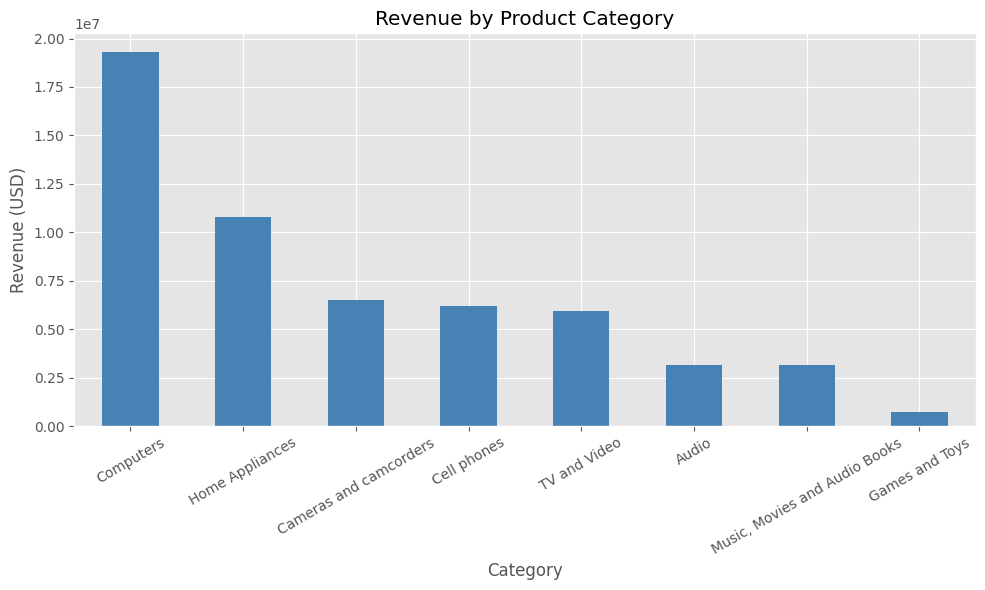

In [45]:
plt.figure(figsize=(10,6))

category_revenue.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (USD)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Insight

This visualization identifies the highest revenue-generating product categories. High-performing categories represent the core business drivers, while lower-performing categories may require pricing, marketing, or inventory optimization.

# Business Question 6

## Which brands generate the highest revenue?

In [46]:
brand_revenue = (
    sales_products
    .groupby("brand")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

brand_revenue.head(10)

brand
Adventure Works         11849909.32
Contoso                 10792325.32
Wide World Importers     9172800.41
Fabrikam                 6807893.52
The Phone Company        5386820.00
Proseware                3212628.02
Litware                  2659498.78
Southridge Video         2578595.93
A. Datum                 1486207.80
Northwind Traders        1126069.54
Name: Revenue, dtype: float64

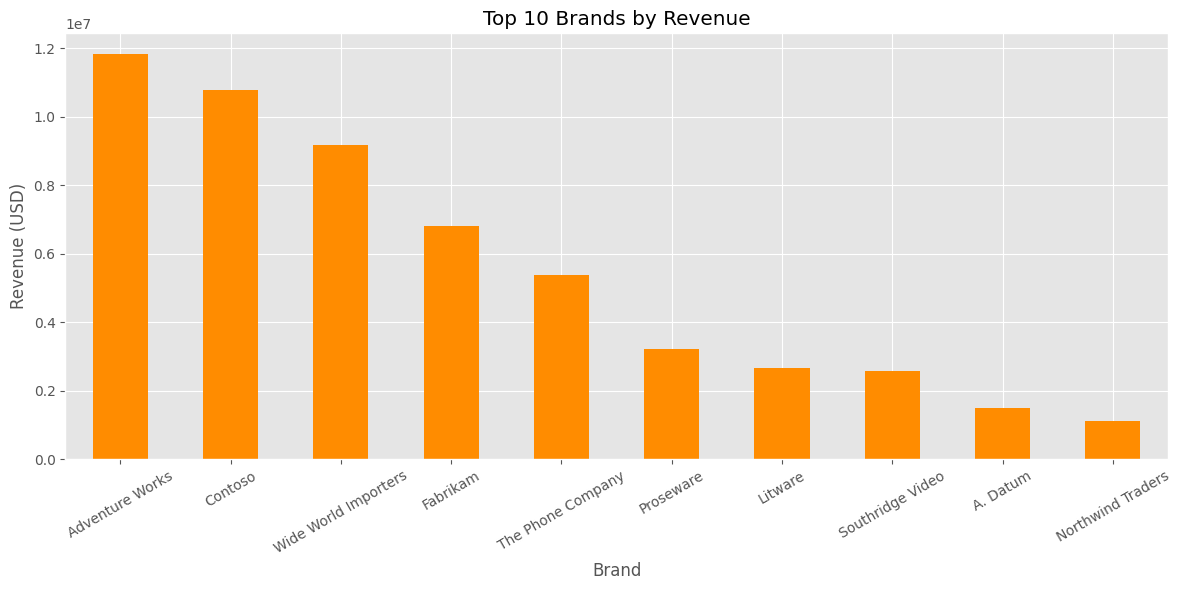

In [47]:
plt.figure(figsize=(12,6))

brand_revenue.head(10).plot(
    kind="bar",
    color="darkorange"
)

plt.title("Top 10 Brands by Revenue")
plt.xlabel("Brand")
plt.ylabel("Revenue (USD)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Insight

The chart highlights the brands contributing the highest sales revenue. These brands are valuable business assets and should be prioritized for inventory availability and promotional campaigns.

# Business Question 7

## Which products sell the most units?

In [48]:
top_quantity = (
    sales_products
    .groupby("product_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_quantity

product_name
WWI Desktop PC2.33 X2330 Black                550
WWI Desktop PC1.80 E1800 White                538
Adventure Works Desktop PC2.30 MD230 White    521
Adventure Works Desktop PC1.60 ED160 Black    521
Adventure Works Desktop PC1.80 ED180 Black    520
Adventure Works Desktop PC2.30 MD230 Black    514
WWI Desktop PC1.60 E1600 Black                509
WWI Desktop PC1.60 E1600 Silver               507
WWI Desktop PC1.80 E1801 Black                505
WWI Desktop PC1.60 E1600 Red                  505
Name: quantity, dtype: int64

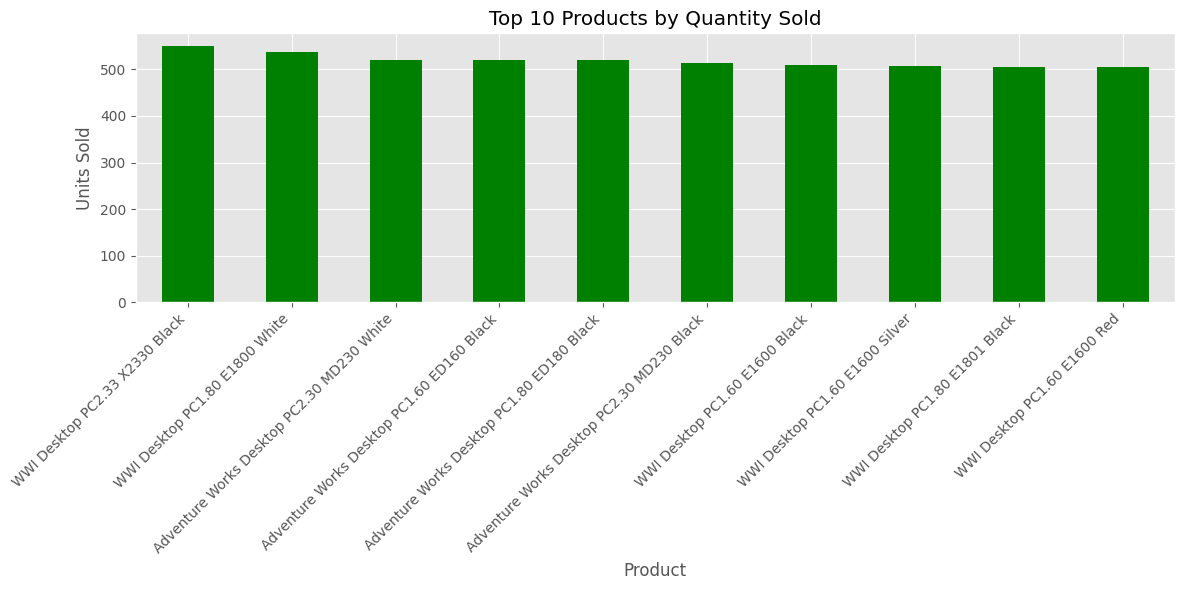

In [49]:
plt.figure(figsize=(12,6))

top_quantity.plot(
    kind="bar",
    color="green"
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product")
plt.ylabel("Units Sold")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Insight

The highest-selling products by quantity indicate customer demand rather than profitability. Comparing this analysis with revenue helps identify premium products versus high-volume products.

# Business Question 8

## How has revenue changed over time?

Analyzing monthly revenue trends helps identify seasonality, business growth, and demand fluctuations.

In [50]:
sales_products["order_date"] = pd.to_datetime(
    sales_products["order_date"]
)

sales_products["Month"] = (
    sales_products["order_date"]
    .dt.to_period("M")
)

In [51]:
monthly_revenue = (
    sales_products
    .groupby("Month")["Revenue"]
    .sum()
)

monthly_revenue

Month
2016-01    649918.78
2016-02    891098.30
2016-03    338407.36
2016-04    110591.63
2016-05    595986.18
             ...    
2020-10    245647.59
2020-11    256701.02
2020-12    651526.44
2021-01    513021.58
2021-02    526266.90
Freq: M, Name: Revenue, Length: 62, dtype: float64

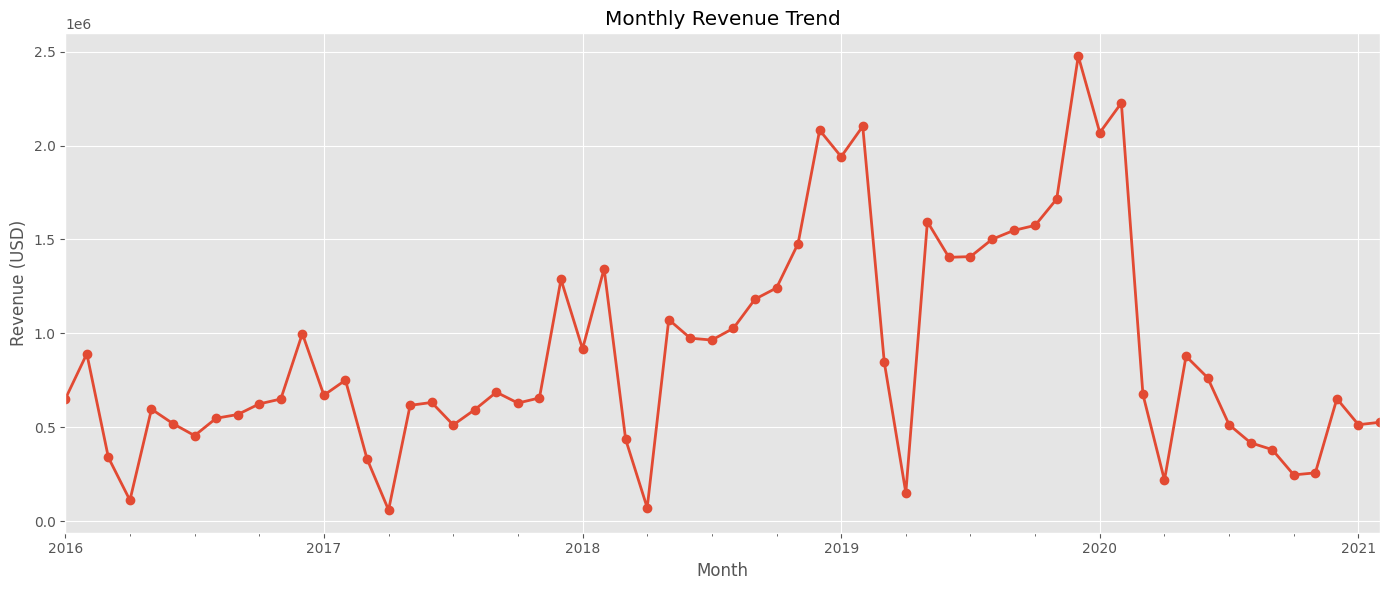

In [52]:
plt.figure(figsize=(14,6))

monthly_revenue.plot(
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (USD)")

plt.grid(True)

plt.tight_layout()

plt.show()

### Insight

The monthly revenue trend helps identify seasonal demand patterns, revenue growth, and periods of strong or weak sales performance. These insights support forecasting and business planning.

# Business Question 9

## Which countries generate the highest revenue?

In [53]:
sales_customer = sales_products.merge(
    customers,
    on="customerkey",
    how="left"
)

sales_customer.head()

,order_number,line_item,order_date,delivery_date,customerkey,storekey,productkey,quantity,currency_code,product_name,brand,color,unit_cost_usd,unit_price_usd,subcategorykey,subcategory,categorykey,category,Revenue,Month,gender,name,city,state_code,state,zip_code,country,continent,birthday
0,366000,1,2016-01-01,NaN,265598,10,1304,1,CAD,Contoso Lens Adapter M450 White,Contoso,White,$31.27,68.00,406,Cameras & Camcorders Accessories,4,Cameras and camcorders,68.00,2016-01,Male,Tyler Vaught,London,ON,Ontario,N5W 5K6,Canada,North America,3/23/1971
1,366001,1,2016-01-01,1/13/2016,1269051,0,1048,2,USD,A. Datum SLR Camera X136 Silver,A. Datum,Silver,$141.47,427.00,402,Digital SLR Cameras,4,Cameras and camcorders,854.00,2016-01,Male,Frank Upchurch,Auberry,CA,California,93602,United States,North America,11/20/1995
2,366001,2,2016-01-01,1/13/2016,1269051,0,2007,1,USD,Fabrikam Microwave 1.5CuFt X1100 Black,Fabrikam,Black,$220.64,665.94,803,Microwaves,8,Home Appliances,665.94,2016-01,Male,Frank Upchurch,Auberry,CA,California,93602,United States,North America,11/20/1995
3,366002,1,2016-01-01,1/12/2016,266019,0,1106,7,CAD,Contoso SLR Camera M146 Orange,Contoso,Orange,$148.08,322.00,402,Digital SLR Cameras,4,Cameras and camcorders,2254.00,2016-01,Female,Joan Roche,Red Deer,AB,Alberta,T4N 2A6,Canada,North America,8/24/1962
4,366002,2,2016-01-01,1/12/2016,266019,0,373,1,CAD,Adventure Works Laptop8.9 E0890 White,Adventure Works,White,$166.20,326.00,301,Laptops,3,Computers,326.00,2016-01,Female,Joan Roche,Red Deer,AB,Alberta,T4N 2A6,Canada,North America,8/24/1962


In [54]:
country_revenue = (
    sales_customer
    .groupby("country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue

country
United States     29871631.17
United Kingdom     7084088.12
Germany            5414149.80
Canada             4724334.63
Australia          2708137.61
Italy              2475645.77
Netherlands        1962154.27
France             1515338.22
Name: Revenue, dtype: float64

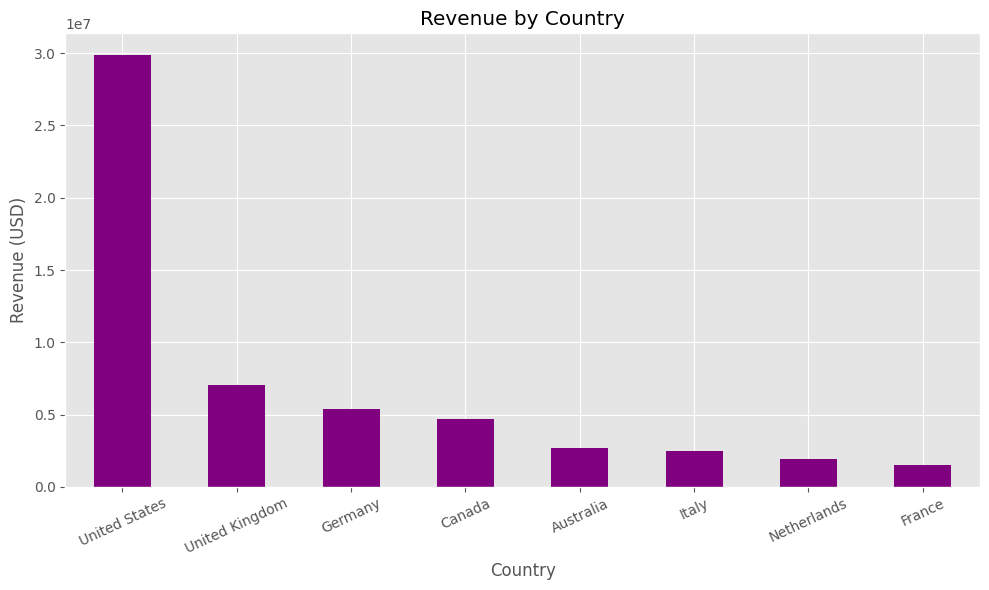

In [55]:
plt.figure(figsize=(10,6))

country_revenue.plot(
    kind="bar",
    color="purple"
)

plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue (USD)")

plt.xticks(rotation=25)

plt.tight_layout()

plt.show()

### Insight

This analysis identifies the countries contributing the highest sales revenue. High-performing markets can be targeted for expansion, while lower-performing regions may require localized marketing or pricing strategies.

# Business Question 10

## Which stores generate the highest revenue?

In [56]:
sales_store = sales_products.merge(
    stores,
    on="storekey",
    how="left"
)

sales_store.head()

,order_number,line_item,order_date,delivery_date,customerkey,storekey,productkey,quantity,currency_code,product_name,brand,color,unit_cost_usd,unit_price_usd,subcategorykey,subcategory,categorykey,category,Revenue,Month,country,state,square_meters,open_date
0,366000,1,2016-01-01,NaN,265598,10,1304,1,CAD,Contoso Lens Adapter M450 White,Contoso,White,$31.27,68.00,406,Cameras & Camcorders Accessories,4,Cameras and camcorders,68.00,2016-01,Canada,Nunavut,1210.0,4/4/2015
1,366001,1,2016-01-01,1/13/2016,1269051,0,1048,2,USD,A. Datum SLR Camera X136 Silver,A. Datum,Silver,$141.47,427.00,402,Digital SLR Cameras,4,Cameras and camcorders,854.00,2016-01,Online,Online,NaN,1/1/2010
2,366001,2,2016-01-01,1/13/2016,1269051,0,2007,1,USD,Fabrikam Microwave 1.5CuFt X1100 Black,Fabrikam,Black,$220.64,665.94,803,Microwaves,8,Home Appliances,665.94,2016-01,Online,Online,NaN,1/1/2010
3,366002,1,2016-01-01,1/12/2016,266019,0,1106,7,CAD,Contoso SLR Camera M146 Orange,Contoso,Orange,$148.08,322.00,402,Digital SLR Cameras,4,Cameras and camcorders,2254.00,2016-01,Online,Online,NaN,1/1/2010
4,366002,2,2016-01-01,1/12/2016,266019,0,373,1,CAD,Adventure Works Laptop8.9 E0890 White,Adventure Works,White,$166.20,326.00,301,Laptops,3,Computers,326.00,2016-01,Online,Online,NaN,1/1/2010


In [57]:
store_revenue = (
    sales_store
    .groupby("country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

store_revenue

country
United States     23764425.86
Online            11404324.63
United Kingdom     5749769.78
Germany            4246279.22
Canada             3611561.79
Australia          2099141.07
Italy              2059086.81
Netherlands        1591344.48
France             1229545.95
Name: Revenue, dtype: float64

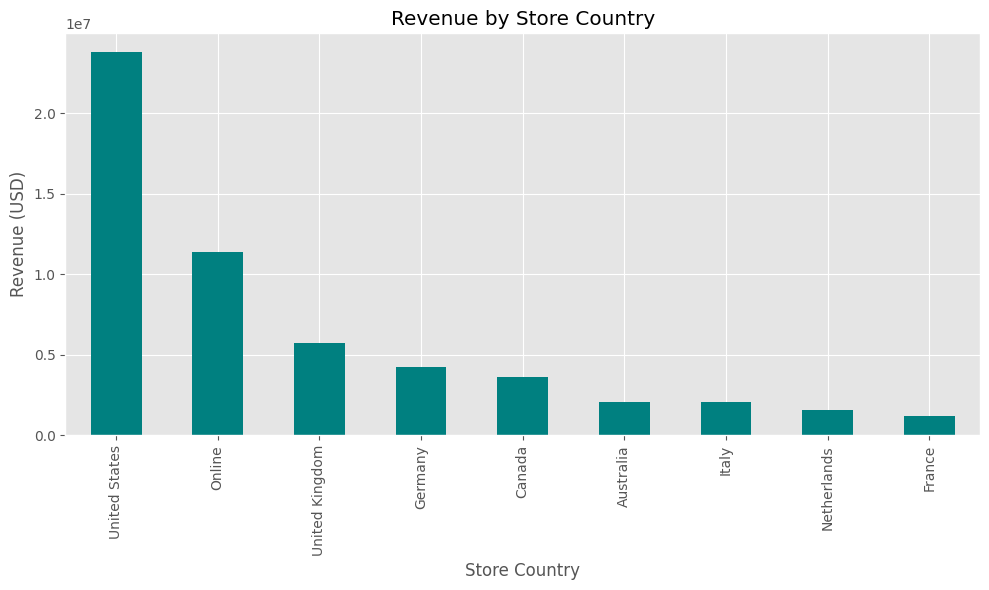

In [58]:
plt.figure(figsize=(10,6))

store_revenue.plot(
    kind="bar",
    color="teal"
)

plt.title("Revenue by Store Country")
plt.xlabel("Store Country")
plt.ylabel("Revenue (USD)")

plt.tight_layout()

plt.show()

### Insight

Store performance analysis highlights the geographical distribution of revenue. This information helps management optimize inventory allocation, staffing, and regional investments.

# Exploratory Data Analysis Summary

## Key Findings

- Total revenue was calculated by combining sales transactions with product pricing.
- Product performance was evaluated using both revenue and units sold.
- Revenue distribution across categories and brands highlighted the strongest business segments.
- Monthly revenue trends revealed sales patterns over time.
- Country-level analysis identified the most valuable customer markets.
- Store-level analysis provided insights into geographical business performance.

These findings will be validated using SQL in the next stage and later visualized through an interactive Power BI dashboard.